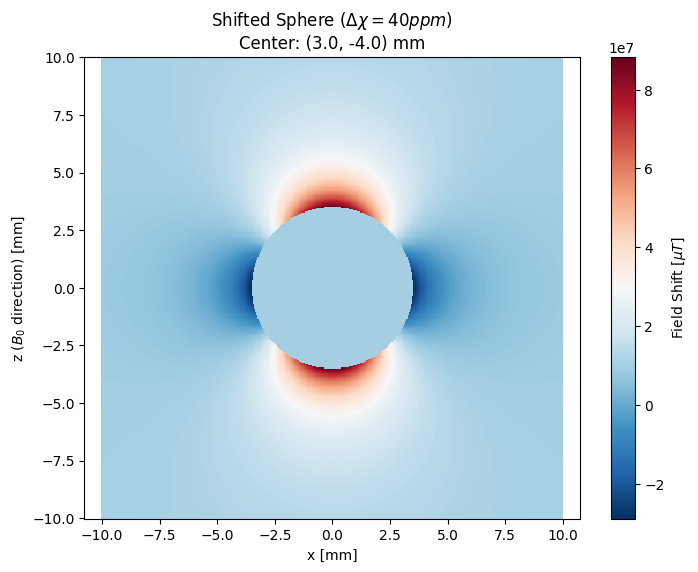

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def generate_shifted_sphere_field_map_mm(
    grid_size_pixels: int = 400,
    extent_mm: float = 20.0,
    radius_a_mm: float = 3.5,
    center_x_mm: float = 3.0,
    center_z_mm: float = -4.0,
    chi_i: float = 50.0e-6,
    chi_e: float = 10.0e-6,
    B0_T: float = 3.0
):
    """
    Generates a 2D field map of a sphere shifted in the x and z directions.
    
    Parameters:
    -----------
    grid_size_pixels : int
        Resolution of the output map.
    extent_mm : float
        The physical size of the field of view in millimeters [mm].
    radius_a_mm : float
        The radius of the sphere in millimeters [mm].
    center_x_mm : float
        The x-position of the sphere center [mm].
    center_z_mm : float
        The z-position (along B0) of the sphere center [mm].
    chi_i_ppm : float
        Internal susceptibility in ppm.
    chi_e_ppm : float
        External susceptibility in ppm.
    B0_T : float
        Main magnetic field strength in Tesla [T].
    """
    
    # Create coordinate grid
    coords = np.linspace(-extent_mm/2, extent_mm/2, grid_size_pixels)
    X_mm, Z_mm = np.meshgrid(coords, coords)
    
    # Calculate relative distance from the shifted center
    X_rel = X_mm - center_x_mm
    Z_rel = Z_mm - center_z_mm
    
    # Spherical coordinates relative to the shifted center
    R = np.sqrt(X_rel**2 + Z_rel**2)
    R_safe = np.where(R == 0, 1e-12, R) # Avoid division by zero
    CosTheta = Z_rel / R_safe
    
    # Baseline (k=0 term)
    baseline_T = (1/3) * chi_e * B0_T
    
    field_map_T = np.zeros_like(X_mm)
    internal_mask = R <= radius_a_mm
    external_mask = R > radius_a_mm
    
    # Internal Field: 1/3 * chi_e * B0
    field_map_T[internal_mask] = baseline_T
    
    # External Field: Dipole perturbation centered at (center_x, center_z)
    delta_chi = chi_i - chi_e
    dipole_geometry = (radius_a_mm**3 / R_safe[external_mask]**3) * (3 * CosTheta[external_mask]**2 - 1)
    
    field_map_T[external_mask] = (1/3) * delta_chi * dipole_geometry * B0_T + baseline_T
    
    return X_mm, Z_mm, field_map_T

# --- Example Usage ---

# Parameters
EXTENT_MM = 20.0     # 20 mm FOV
RADIUS_MM = 3.5      # 3.5 mm sphere
SHIFT_X_MM = 0.0     # Shifted 3 mm right
SHIFT_Z_MM = 0.0    # Shifted 4 mm down
CHI_I = 100e-6
CHI_E = 10e-6
B0_T = 3.0 # in tesla

X, Z, field = generate_shifted_sphere_field_map_mm(
    extent_mm=EXTENT_MM, radius_a_mm=RADIUS_MM, 
    center_x_mm=SHIFT_X_MM, center_z_mm=SHIFT_Z_MM,
    chi_i=50, chi_e=10, B0_T=B0_T
)

# Plotting
plt.figure(figsize=(8, 6))
field_uT = field * 1e6 # Scale to microTesla

im = plt.pcolormesh(X, Z, field_uT, shading='auto', cmap='RdBu_r')
plt.colorbar(im, label='Field Shift [$\mu T$]')
plt.title(f'Shifted Sphere ($\Delta\chi=40 ppm$)\nCenter: ({SHIFT_X}, {SHIFT_Z}) mm')
plt.xlabel('x [mm]')
plt.ylabel('z ($B_0$ direction) [mm]')

plt.axis('equal')
plt.show()

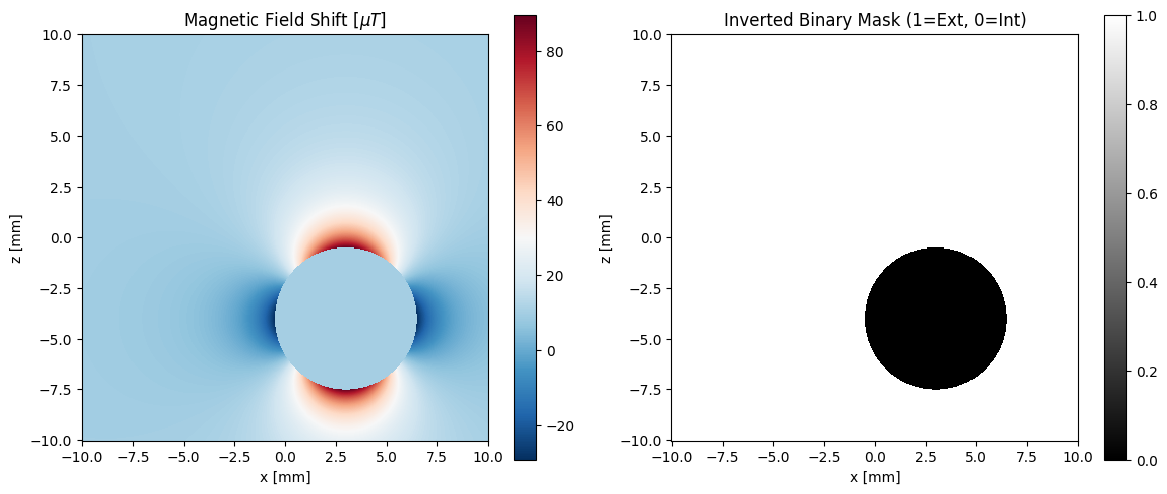

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def generate_shifted_sphere_field_map_mm(
    grid_size_pixels: int = 400,
    extent_mm: float = 20.0,
    radius_a_mm: float = 3.5,
    center_x_mm: float = 3.0,
    center_z_mm: float = -4.0,
    chi_i: float = 50.0e-6,
    chi_e: float = 10.0e-6,
    B0_T: float = 3.0
):
    """
    Generates a 2D field map of a sphere shifted in the x and z directions.
    Also returns an inverted binary mask (1 for background, 0 for sphere).
    
    Returns:
    --------
    X_mm, Z_mm, field_map_T, inverted_mask
    """
    
    # Create coordinate grid
    coords = np.linspace(-extent_mm/2, extent_mm/2, grid_size_pixels)
    X_mm, Z_mm = np.meshgrid(coords, coords)
    
    # Calculate relative distance from the shifted center
    X_rel = X_mm - center_x_mm
    Z_rel = Z_mm - center_z_mm
    
    # Spherical coordinates relative to the shifted center
    R = np.sqrt(X_rel**2 + Z_rel**2)
    R_safe = np.where(R == 0, 1e-12, R) # Avoid division by zero
    CosTheta = Z_rel / R_safe
    
    # Baseline (k=0 term)
    baseline_T = (1/3) * chi_e * B0_T
    
    field_map_T = np.zeros_like(X_mm)
    internal_mask = R <= radius_a_mm
    external_mask = R > radius_a_mm
    
    # --- Generate Inverted Mask ---
    # ~internal_mask flips True to False and False to True. 
    # .astype(int) converts True/False to 1/0.
    inverted_mask = (~internal_mask).astype(int)
    
    # Internal Field: 1/3 * chi_e * B0
    field_map_T[internal_mask] = baseline_T
    
    # External Field: Dipole perturbation centered at (center_x, center_z)
    delta_chi = chi_i - chi_e
    dipole_geometry = (radius_a_mm**3 / R_safe[external_mask]**3) * (3 * CosTheta[external_mask]**2 - 1)
    
    field_map_T[external_mask] = (1/3) * delta_chi * dipole_geometry * B0_T + baseline_T
    
    return X_mm, Z_mm, field_map_T, inverted_mask

# --- Testing the output ---
X, Z, field, mask = generate_shifted_sphere_field_map_mm()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Field Map
im0 = ax[0].pcolormesh(X, Z, field * 1e6, cmap='RdBu_r', shading='auto')
ax[0].set_title("Magnetic Field Shift [$\mu T$]")
plt.colorbar(im0, ax=ax[0])

# Plot Inverted Mask
im1 = ax[1].pcolormesh(X, Z, mask, cmap='gray', shading='auto')
ax[1].set_title("Inverted Binary Mask (1=Ext, 0=Int)")
plt.colorbar(im1, ax=ax[1])

for a in ax:
    a.set_aspect('equal')
    a.set_xlabel('x [mm]')
    a.set_ylabel('z [mm]')

plt.tight_layout()
plt.show()